Using device: cuda
Dataset found at: /kaggle/input/datasets/arjunrg/rdataset/ns_V1e-3_N5000_T50.mat
Keys in dataset: ['a', 't', 'u']
Shape of u after transpose: (5000, 64, 64, 50)
Selected time indices: [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 49]
Total parameters: 1189643
Starting training...
Epoch 001 | Train: 2.602560e-01 | Val: 6.966711e-02
Epoch 002 | Train: 5.201533e-02 | Val: 4.463668e-02
Epoch 003 | Train: 4.032536e-02 | Val: 3.734731e-02
Epoch 004 | Train: 3.265614e-02 | Val: 2.942279e-02
Epoch 005 | Train: 2.742170e-02 | Val: 2.624247e-02
Epoch 006 | Train: 2.468415e-02 | Val: 2.411540e-02
Epoch 007 | Train: 2.287221e-02 | Val: 2.330539e-02
Epoch 008 | Train: 2.143319e-02 | Val: 2.133307e-02
Epoch 009 | Train: 2.047536e-02 | Val: 2.046678e-02
Epoch 010 | Train: 1.973901e-02 | Val: 1.947228e-02
Epoch 011 | Train: 1.881913e-02 | Val: 1.931511e-02
Epoch 012 | Train: 1.806233e-02 | Val: 1.802111e-02
Epoch 013 | Train: 1.747463e-02 | Val: 1.692146e-02
Epoch 014 | Train: 1.686665e-02

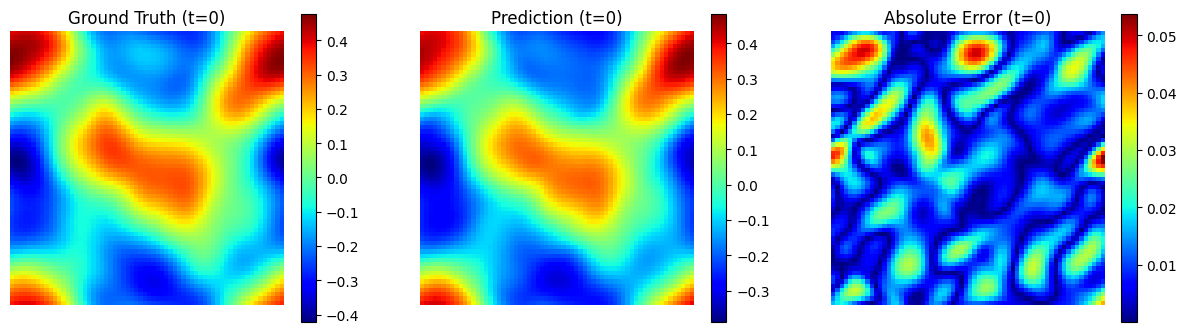

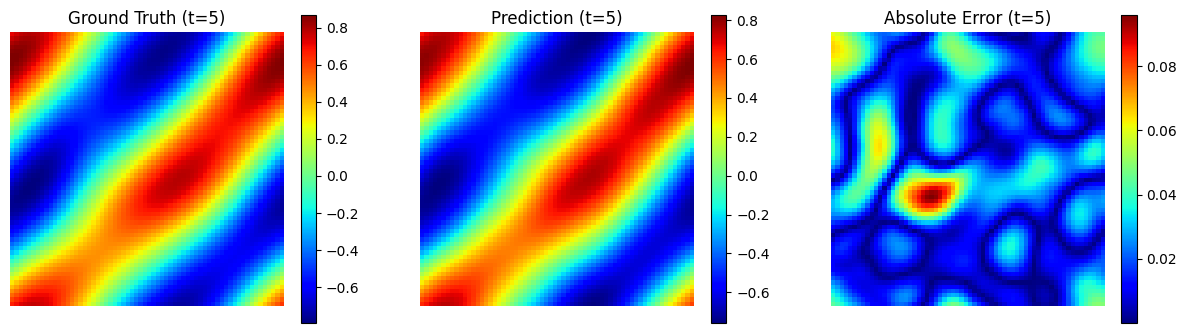

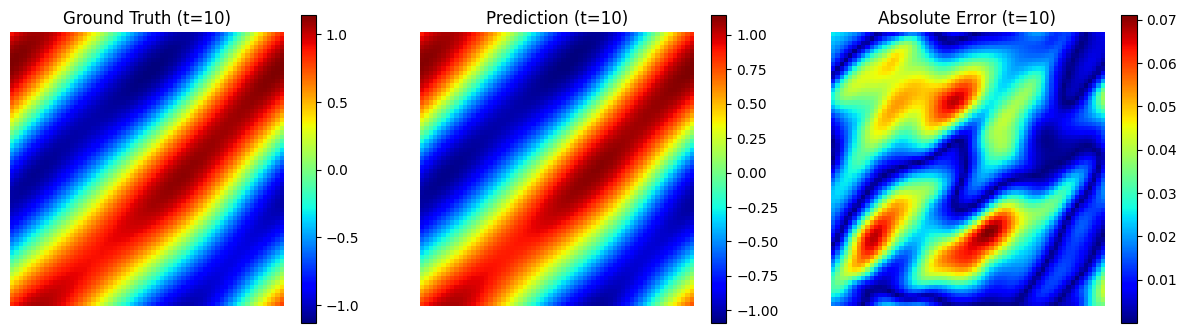

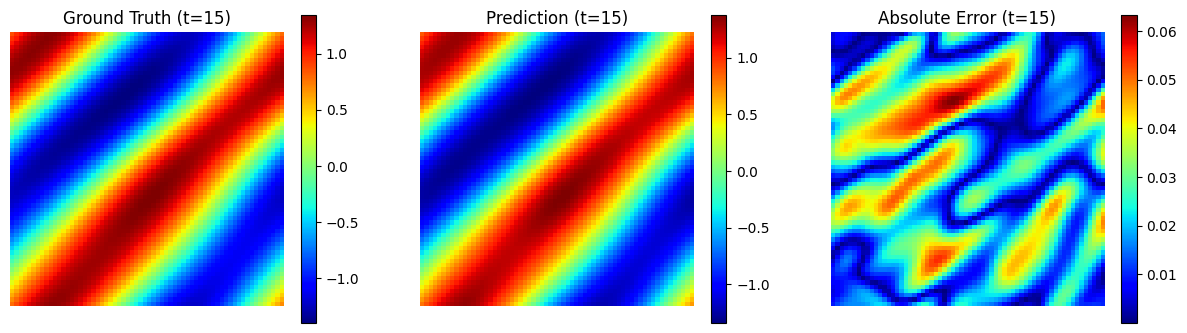

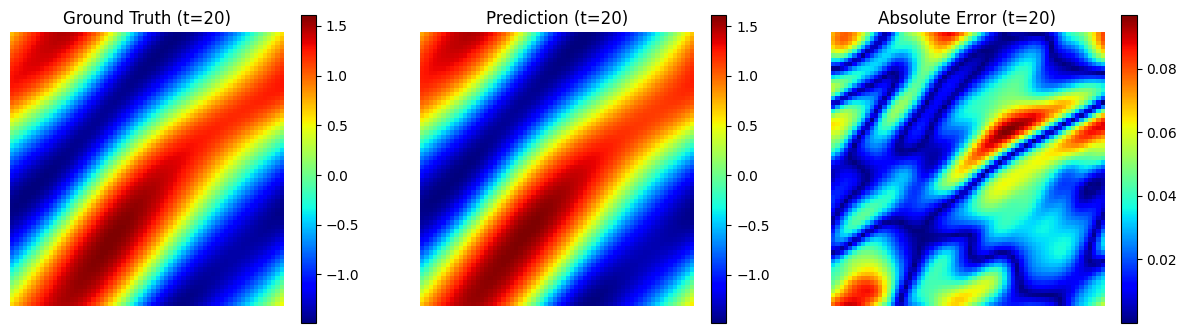

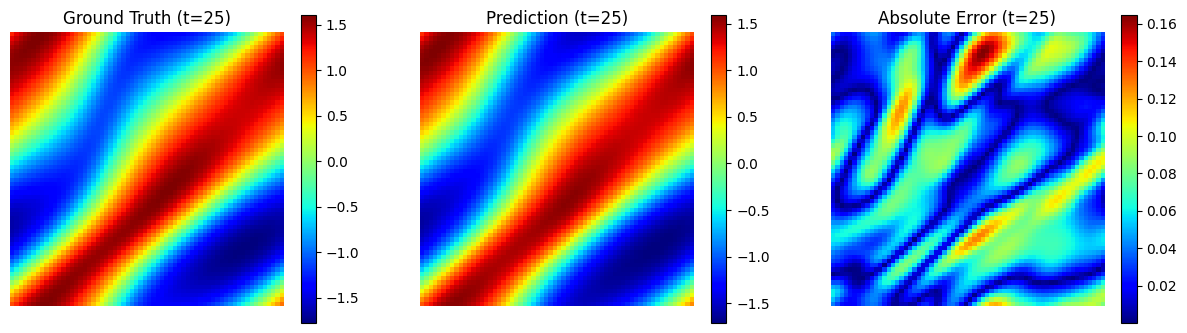

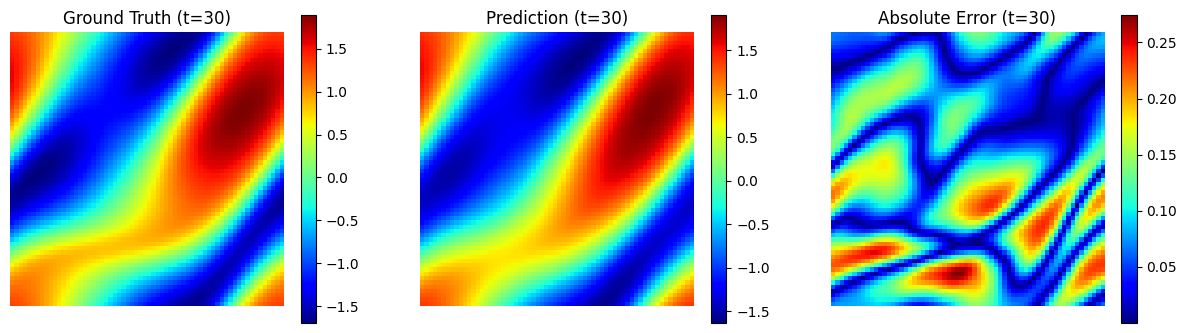

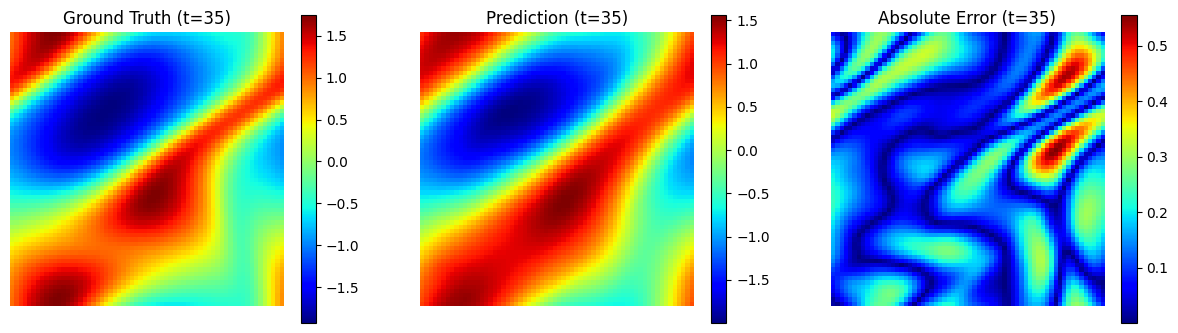

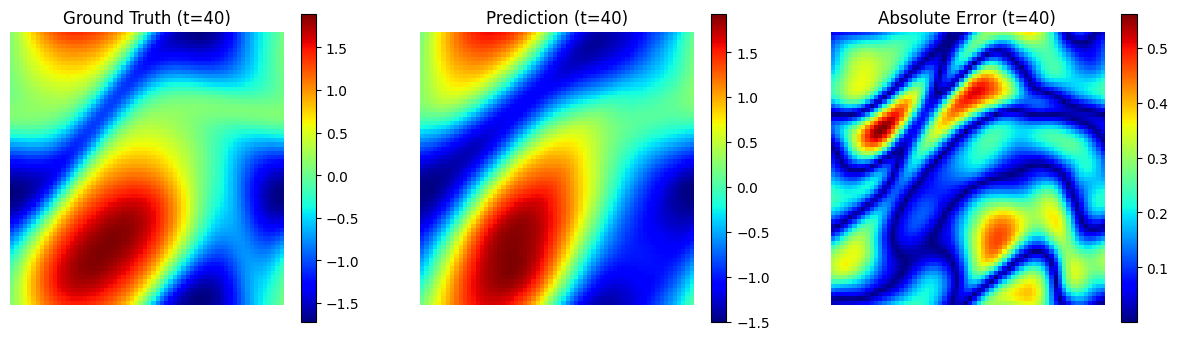

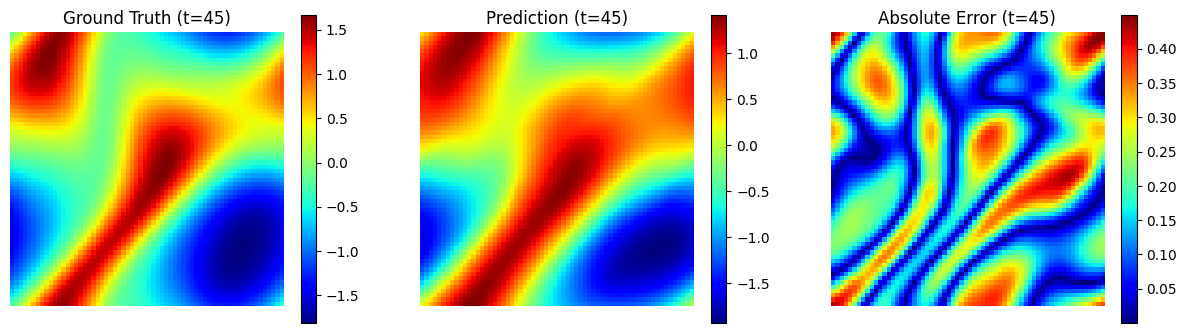

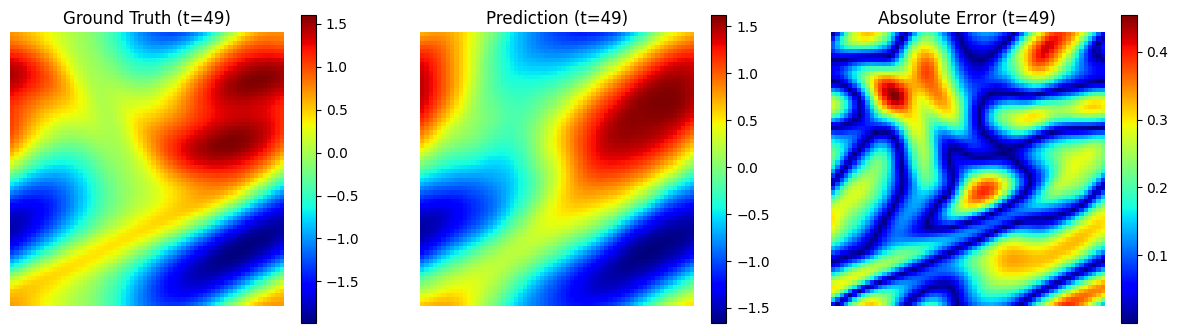

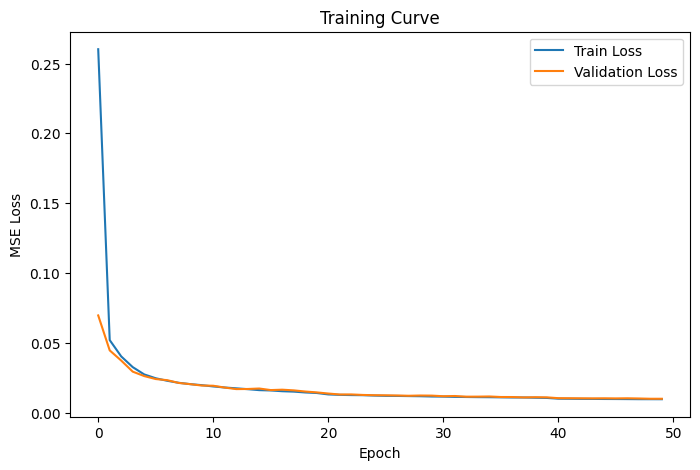

In [1]:
import os
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def find_mat_file(filename="ns_V1e-3_N5000_T50.mat", root="/kaggle/input"):
    for dirname, _, files in os.walk(root):
        if filename in files:
            return os.path.join(dirname, filename)
    raise FileNotFoundError(f"{filename} not found in {root}")

DATA_PATH = find_mat_file()
print("Dataset found at:", DATA_PATH)

with h5py.File(DATA_PATH, 'r') as f:
    print("Keys in dataset:", list(f.keys()))
    u = np.array(f['u'])

# MATLAB stores data in reversed order
u = np.transpose(u, (3, 2, 1, 0))  # (N, Nx, Ny, T)
print("Shape of u after transpose:", u.shape)

N, Nx, Ny, T = u.shape

# Select Time Steps: 0,5,10,...,50

time_indices = list(range(0, T, 5))
if time_indices[-1] != T - 1:
    time_indices.append(T - 1)

print("Selected time indices:", time_indices)
num_times = len(time_indices)

x_data = u[:, :, :, 0]                    
y_data = u[:, :, :, time_indices]          

x_data = torch.tensor(x_data, dtype=torch.float32).unsqueeze(1)
y_data = torch.tensor(y_data, dtype=torch.float32)
y_data = y_data.permute(0, 3, 1, 2)        # (N, num_times, Nx, Ny)

ntrain, nval, ntest = 4000, 500, 500
batch_size = 20

x_train, y_train = x_data[:ntrain], y_data[:ntrain]
x_val, y_val = x_data[ntrain:ntrain+nval], y_data[ntrain:ntrain+nval]
x_test, y_test = x_data[-ntest:], y_data[-ntest:]

train_loader = DataLoader(TensorDataset(x_train, y_train),
                          batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(x_val, y_val),
                        batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(x_test, y_test),
                         batch_size=batch_size, shuffle=False)

class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.modes1 = modes1
        self.modes2 = modes2
        scale = 1 / (in_channels * out_channels)

        self.weights1 = nn.Parameter(
            scale * torch.rand(in_channels, out_channels,
                               modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(
            scale * torch.rand(in_channels, out_channels,
                               modes1, modes2, dtype=torch.cfloat))

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        x_ft = torch.fft.rfft2(x)

        out_ft = torch.zeros(
            batchsize,
            self.weights1.shape[1],
            x.size(-2),
            x.size(-1)//2 + 1,
            dtype=torch.cfloat,
            device=x.device
        )

        out_ft[:, :, :self.modes1, :self.modes2] = \
            self.compl_mul2d(
                x_ft[:, :, :self.modes1, :self.modes2],
                self.weights1)

        out_ft[:, :, -self.modes1:, :self.modes2] = \
            self.compl_mul2d(
                x_ft[:, :, -self.modes1:, :self.modes2],
                self.weights2)

        x = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))
        return x

class FNO2d(nn.Module):
    def __init__(self, modes1, modes2, width, out_channels):
        super().__init__()

        self.fc0 = nn.Conv2d(3, width, 1)

        self.conv0 = SpectralConv2d(width, width, modes1, modes2)
        self.conv1 = SpectralConv2d(width, width, modes1, modes2)
        self.conv2 = SpectralConv2d(width, width, modes1, modes2)
        self.conv3 = SpectralConv2d(width, width, modes1, modes2)

        self.w0 = nn.Conv2d(width, width, 1)
        self.w1 = nn.Conv2d(width, width, 1)
        self.w2 = nn.Conv2d(width, width, 1)
        self.w3 = nn.Conv2d(width, width, 1)

        self.fc1 = nn.Conv2d(width, 128, 1)
        self.fc2 = nn.Conv2d(128, out_channels, 1)

    def get_grid(self, shape, device):
        batchsize, _, size_x, size_y = shape
        gridx = torch.linspace(0, 1, size_x, device=device)
        gridy = torch.linspace(0, 1, size_y, device=device)

        gridx = gridx.reshape(1, 1, size_x, 1).repeat(batchsize, 1, 1, size_y)
        gridy = gridy.reshape(1, 1, 1, size_y).repeat(batchsize, 1, size_x, 1)

        return torch.cat((gridx, gridy), dim=1)

    def forward(self, x):
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=1)

        x = self.fc0(x)
        x = F.gelu(self.conv0(x) + self.w0(x))
        x = F.gelu(self.conv1(x) + self.w1(x))
        x = F.gelu(self.conv2(x) + self.w2(x))
        x = F.gelu(self.conv3(x) + self.w3(x))

        x = F.gelu(self.fc1(x))
        x = self.fc2(x)
        return x

modes, width = 12, 32
epochs = 50

model = FNO2d(modes, modes, width, num_times).to(device)
print("Total parameters:", sum(p.numel() for p in model.parameters()))

optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = StepLR(optimizer, step_size=20, gamma=0.5)
criterion = nn.MSELoss()
train_losses, val_losses = [], []

print("Starting training...")
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            val_loss += criterion(pred, y).item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    scheduler.step()

    print(f"Epoch {epoch+1:03d} | Train: {train_loss:.6e} | Val: {val_loss:.6e}")

print("Training Complete!")

model.eval()
test_loss = 0.0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        pred = model(x)
        test_loss += criterion(pred, y).item()

test_loss /= len(test_loader)
print("Final Test Loss:", test_loss)

x_sample, y_true = next(iter(test_loader))
x_sample = x_sample.to(device)

with torch.no_grad():
    y_pred = model(x_sample).cpu()

y_true = y_true[0].numpy()
y_pred = y_pred[0].numpy()

for i, t in enumerate(time_indices):
    gt = y_true[i]
    pred = y_pred[i]
    err = np.abs(gt - pred)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    im0 = axes[0].imshow(gt, cmap="jet")
    axes[0].set_title(f"Ground Truth (t={t})")
    axes[0].axis("off")
    fig.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(pred, cmap="jet")
    axes[1].set_title(f"Prediction (t={t})")
    axes[1].axis("off")
    fig.colorbar(im1, ax=axes[1])

    im2 = axes[2].imshow(err, cmap="jet")
    axes[2].set_title(f"Absolute Error (t={t})")
    axes[2].axis("off")
    fig.colorbar(im2, ax=axes[2])

    plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Curve")
plt.legend()
plt.show()

Using device: cuda
Dataset found at: /kaggle/input/datasets/arjunrg/rdataset/ns_V1e-3_N5000_T50.mat

Pretraining FNO...
Pretrain Epoch 001 | Train: 2.414637e-01 | Val: 6.143751e-02
Pretrain Epoch 002 | Train: 4.712666e-02 | Val: 3.992080e-02
Pretrain Epoch 003 | Train: 3.327060e-02 | Val: 2.934459e-02
Pretrain Epoch 004 | Train: 2.462140e-02 | Val: 2.293325e-02
Pretrain Epoch 005 | Train: 2.011118e-02 | Val: 1.893763e-02
Pretrain Epoch 006 | Train: 1.718088e-02 | Val: 1.660979e-02
Pretrain Epoch 007 | Train: 1.493599e-02 | Val: 1.465169e-02
Pretrain Epoch 008 | Train: 1.334114e-02 | Val: 1.348266e-02
Pretrain Epoch 009 | Train: 1.211348e-02 | Val: 1.212048e-02
Pretrain Epoch 010 | Train: 1.112071e-02 | Val: 1.123543e-02
Pretrain Epoch 011 | Train: 1.029518e-02 | Val: 1.058440e-02
Pretrain Epoch 012 | Train: 9.681796e-03 | Val: 9.989796e-03
Pretrain Epoch 013 | Train: 9.150113e-03 | Val: 9.586839e-03
Pretrain Epoch 014 | Train: 8.737555e-03 | Val: 9.400303e-03
Pretrain Epoch 015 | Train

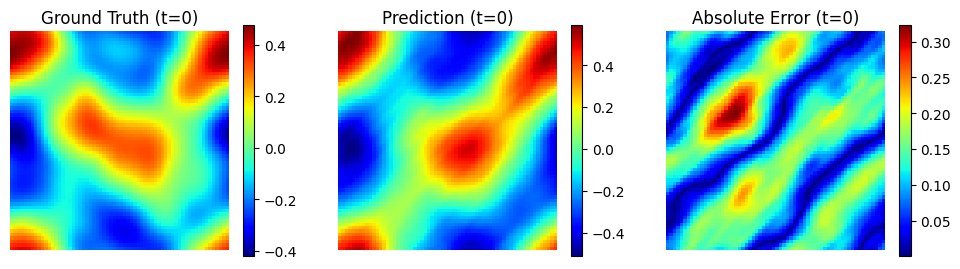

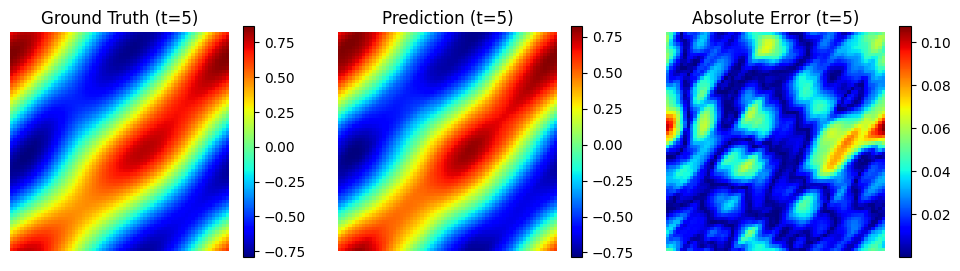

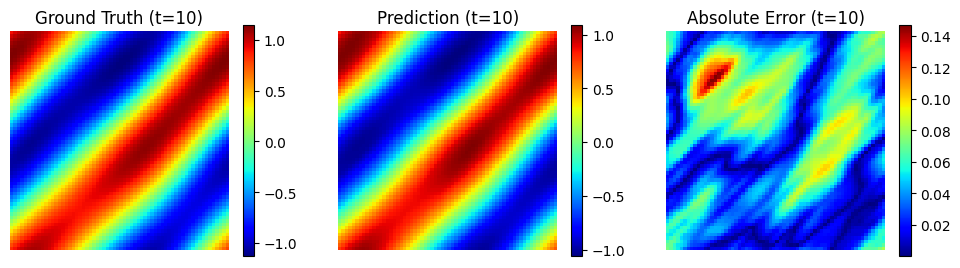

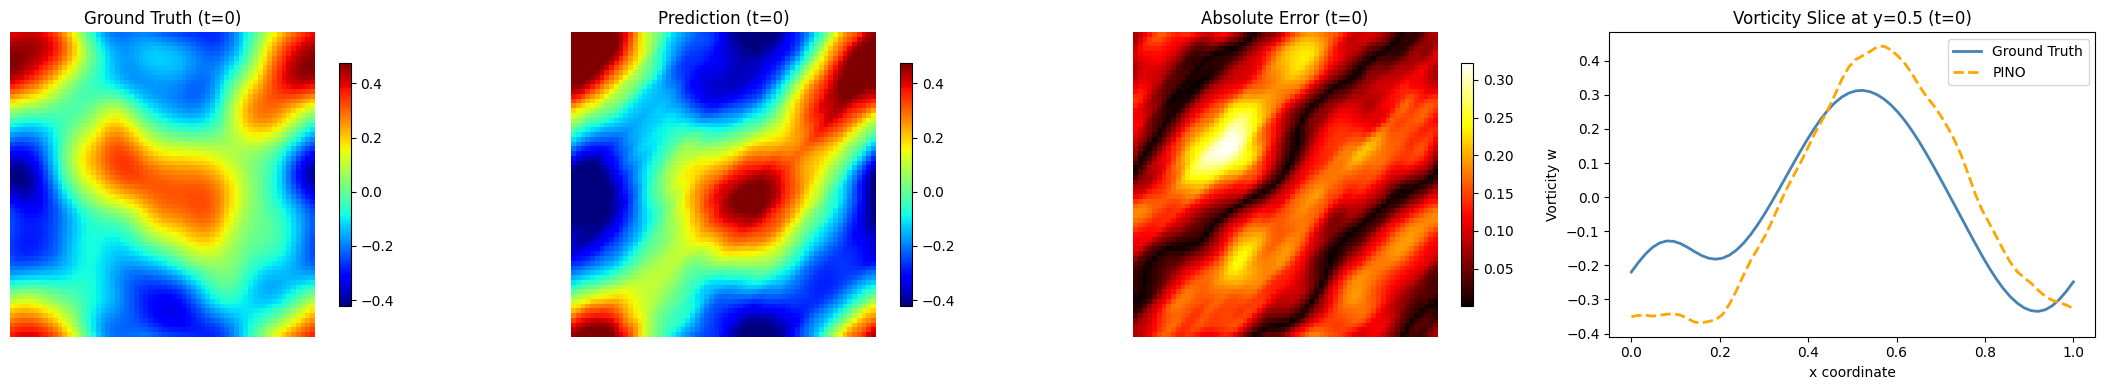

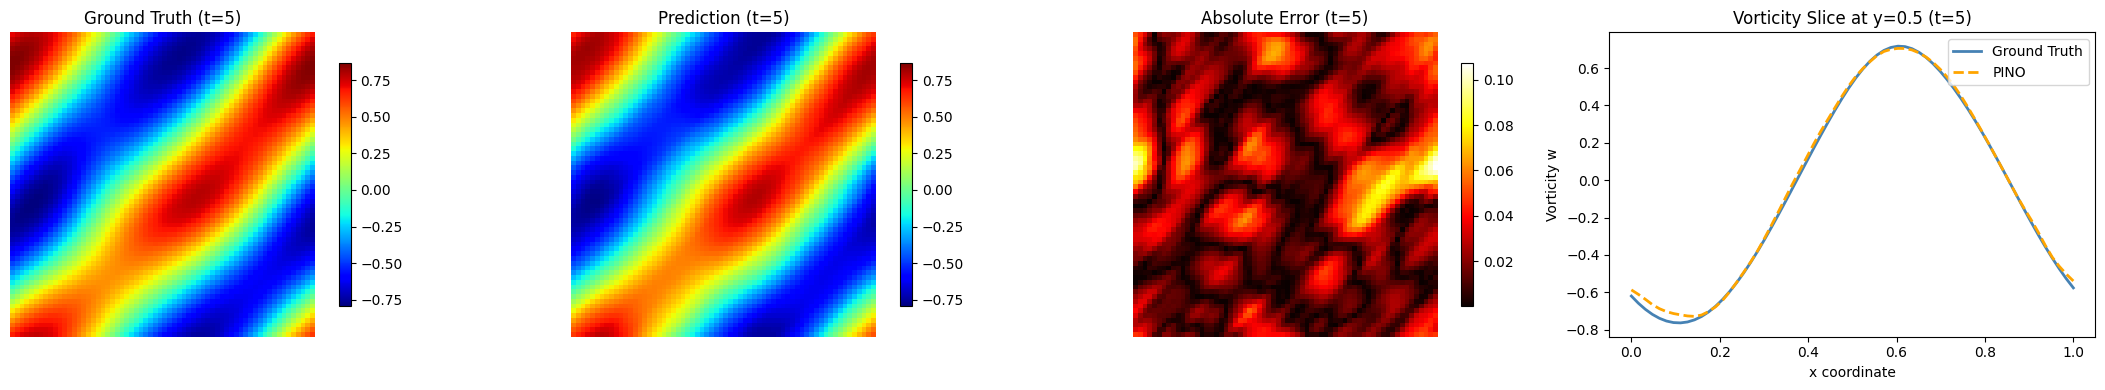

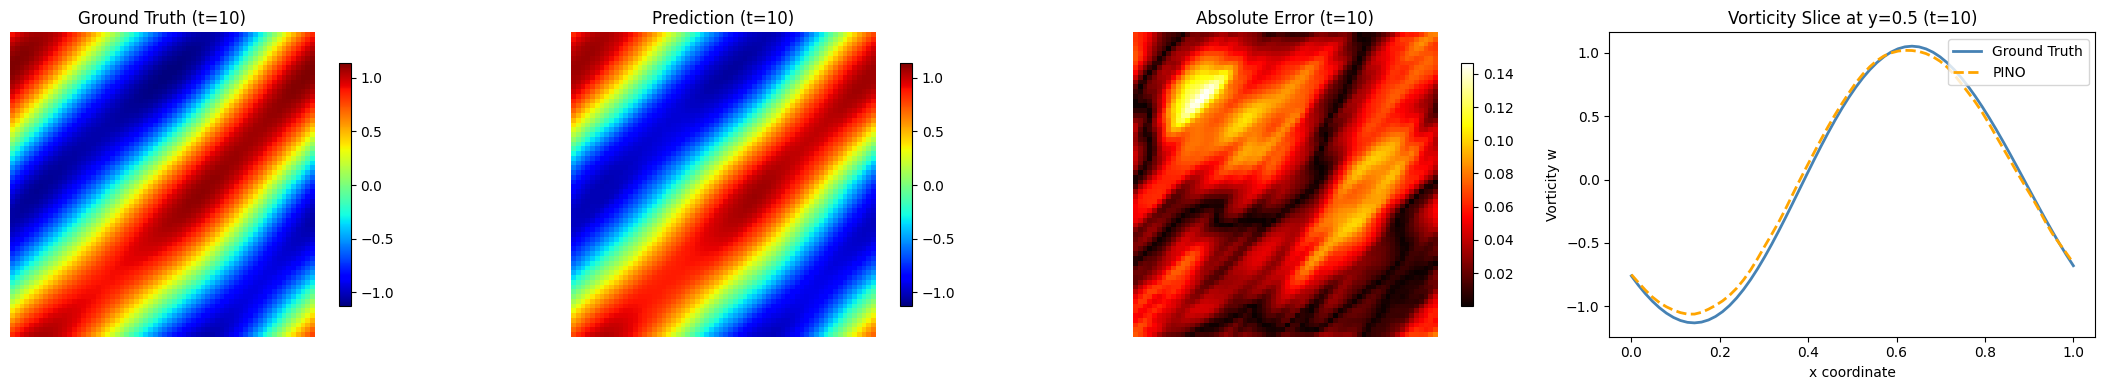

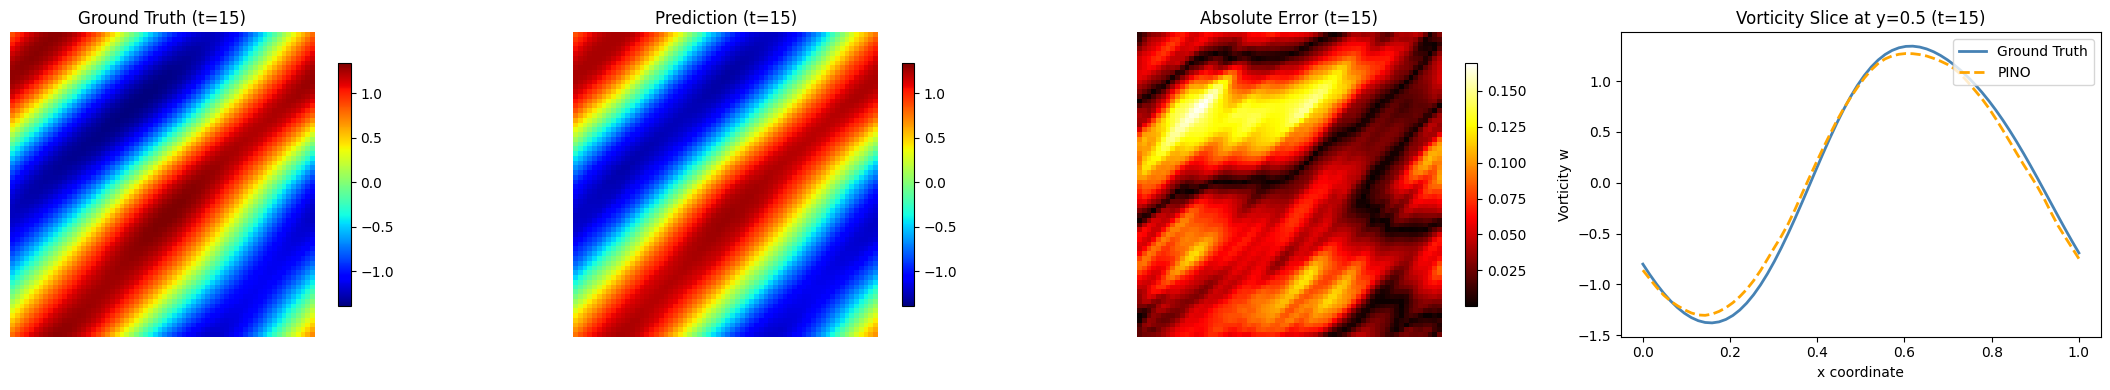

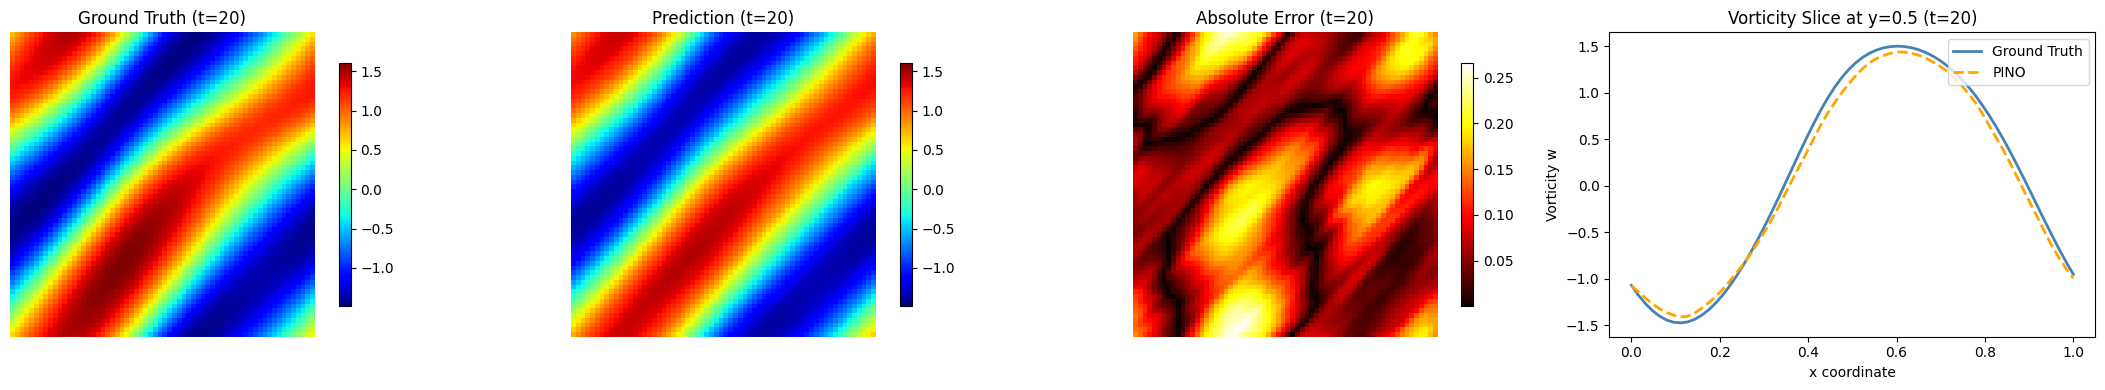

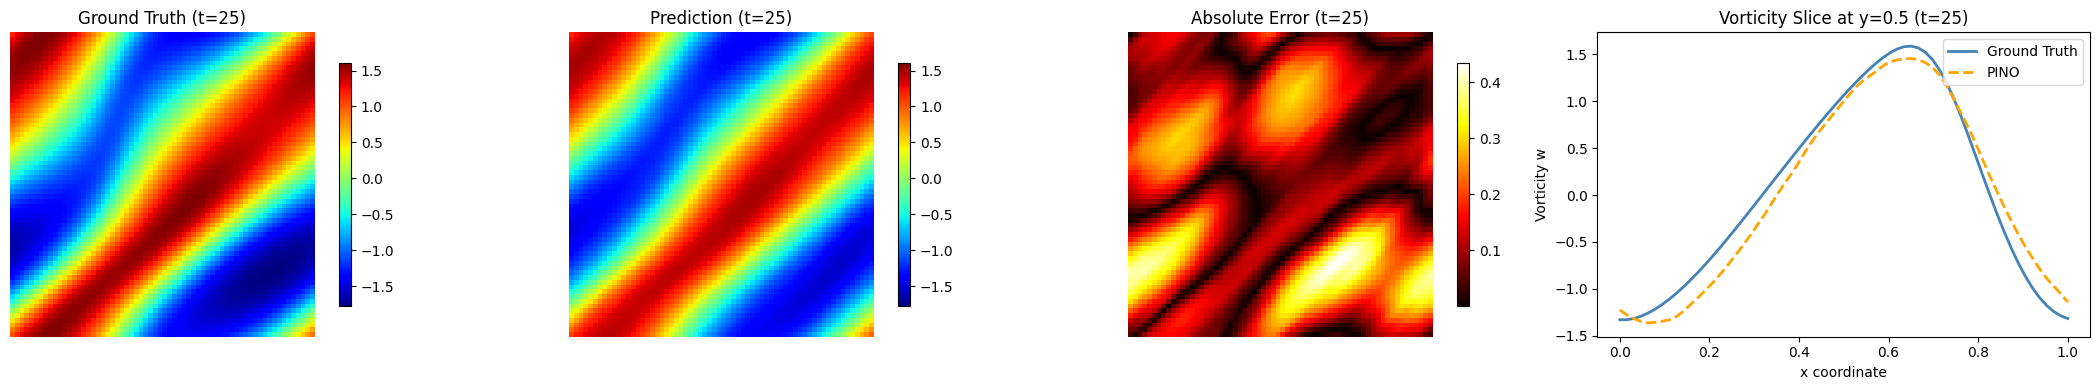

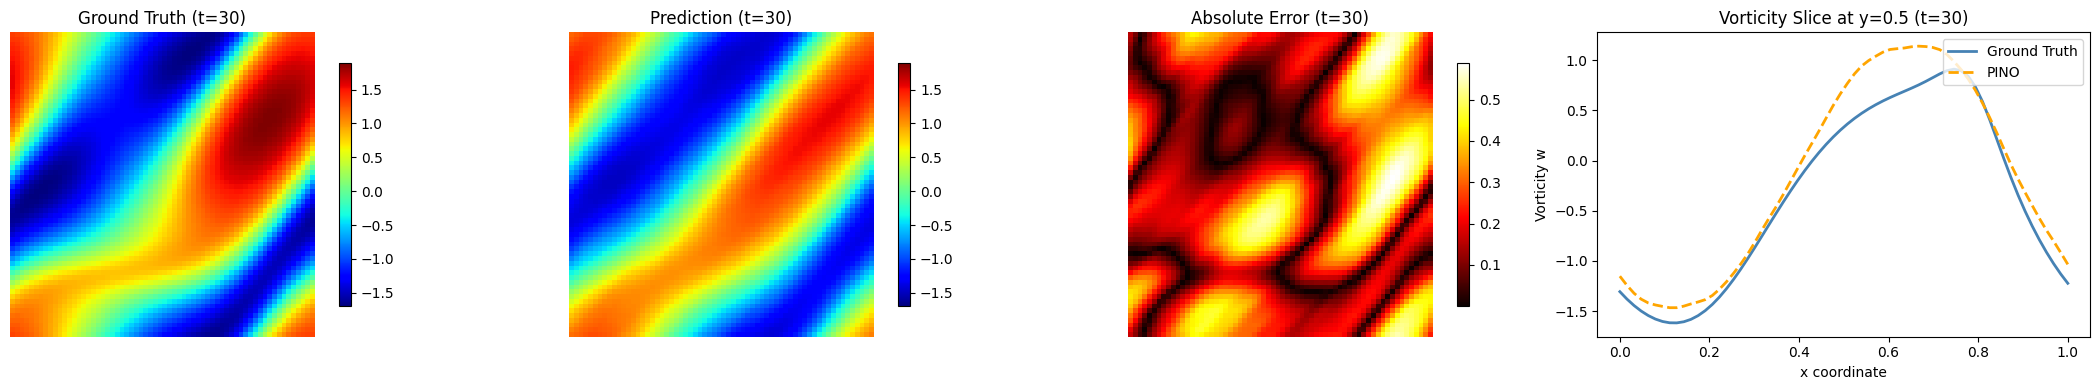

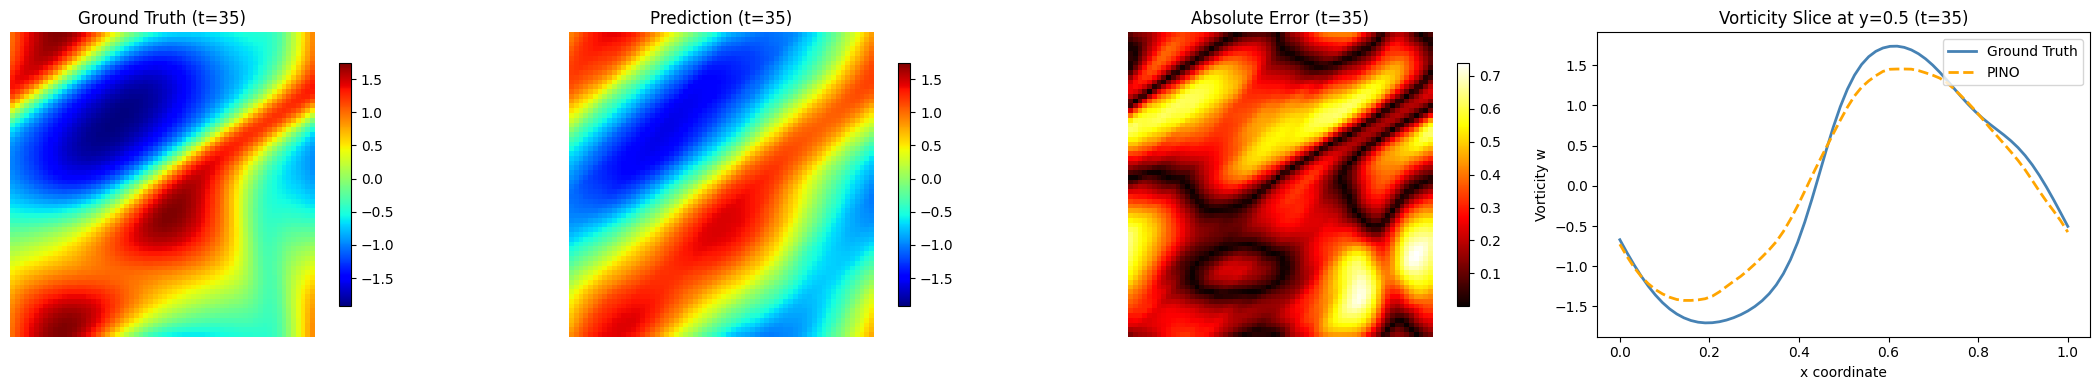

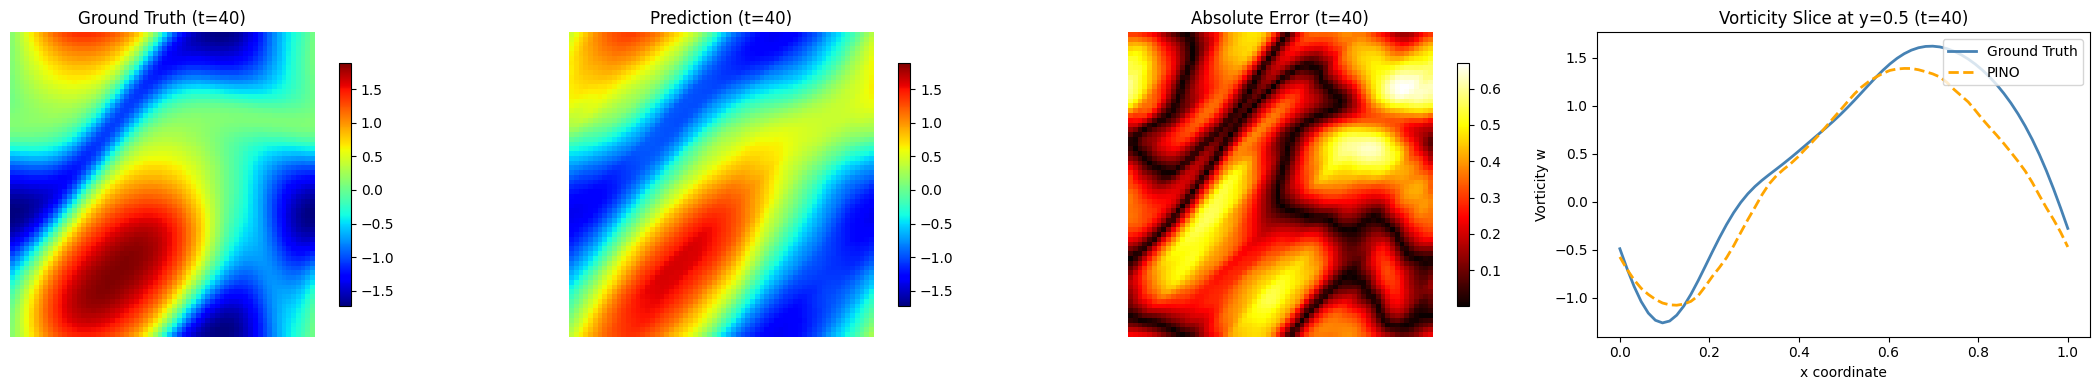

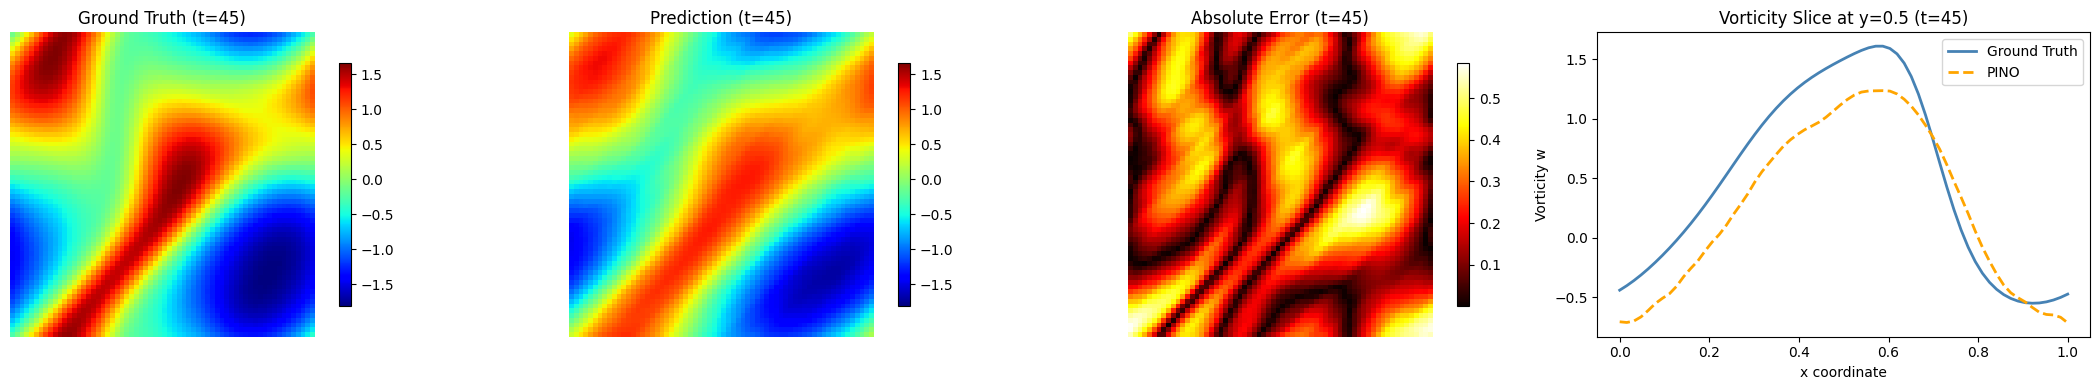

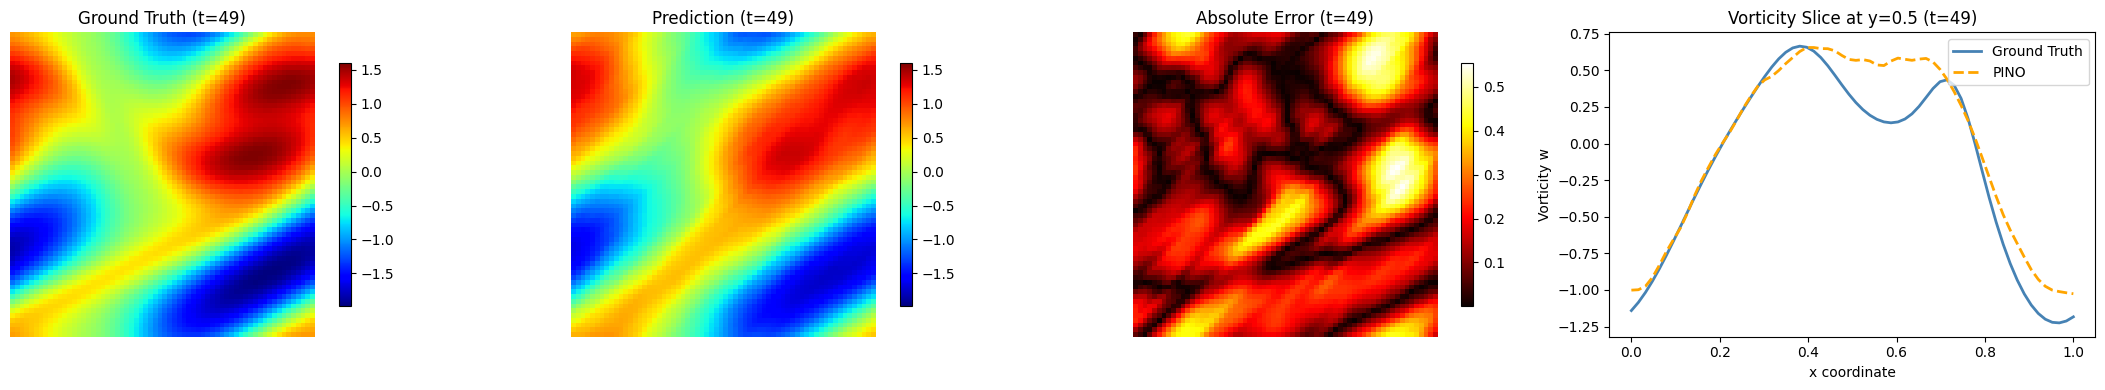

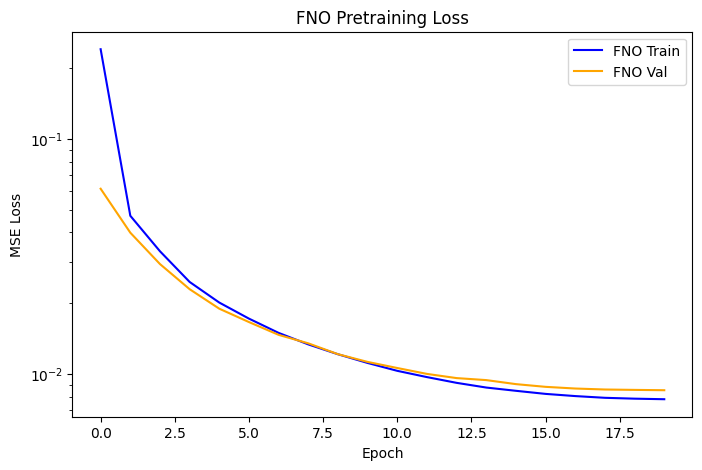

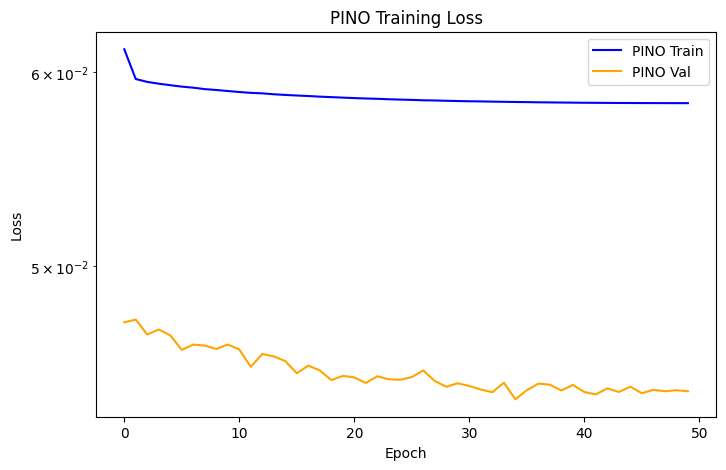

In [2]:
import os
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR


torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def find_mat_file(filename="ns_V1e-3_N5000_T50.mat", root="/kaggle/input"):
    for dirname, _, files in os.walk(root):
        if filename in files:
            return os.path.join(dirname, filename)
    raise FileNotFoundError(f"{filename} not found in {root}")

DATA_PATH = find_mat_file()
print("Dataset found at:", DATA_PATH)

with h5py.File(DATA_PATH, 'r') as f:
    u = np.array(f['u'])

u = np.transpose(u, (3, 2, 1, 0))  
N, Nx, Ny, T = u.shape
# Select Time Steps: 0,5,10,...,50
time_indices = list(range(0, T, 5))
if time_indices[-1] != T - 1:
    time_indices.append(T - 1)

num_times = len(time_indices)
dt = 50.0 / (T - 1)
nu = 1e-3

x_data = u[:, :, :, 0]
y_data = u[:, :, :, time_indices]

x_data = torch.tensor(x_data, dtype=torch.float32).unsqueeze(1)
y_data = torch.tensor(y_data, dtype=torch.float32).permute(0, 3, 1, 2)

# Dataset Split
ntrain, nval, ntest = 4000, 500, 500
batch_size = 20

x_train, y_train = x_data[:ntrain], y_data[:ntrain]
x_val, y_val = x_data[ntrain:ntrain+nval], y_data[ntrain:ntrain+nval]
x_test, y_test = x_data[-ntest:], y_data[-ntest:]

train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(x_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(x_test, y_test), batch_size=batch_size, shuffle=False)


class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        scale = 1 / (in_channels * out_channels)
        self.modes1 = modes1
        self.modes2 = modes2
        self.weights1 = nn.Parameter(scale * torch.rand(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(scale * torch.rand(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        x_ft = torch.fft.rfft2(x)
        out_ft = torch.zeros(batchsize, self.weights1.shape[1], x.size(-2), x.size(-1)//2 + 1, dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes1, :self.modes2] = self.compl_mul2d(x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2] = self.compl_mul2d(x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)
        return torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))

class FNO2d(nn.Module):
    def __init__(self, modes1, modes2, width, out_channels):
        super().__init__()
        self.fc0 = nn.Conv2d(3, width, 1)
        self.conv0 = SpectralConv2d(width, width, modes1, modes2)
        self.conv1 = SpectralConv2d(width, width, modes1, modes2)
        self.conv2 = SpectralConv2d(width, width, modes1, modes2)
        self.conv3 = SpectralConv2d(width, width, modes1, modes2)
        self.w0 = nn.Conv2d(width, width, 1)
        self.w1 = nn.Conv2d(width, width, 1)
        self.w2 = nn.Conv2d(width, width, 1)
        self.w3 = nn.Conv2d(width, width, 1)
        self.fc1 = nn.Conv2d(width, 128, 1)
        self.fc2 = nn.Conv2d(128, out_channels, 1)

    def get_grid(self, shape, device):
        batchsize, _, size_x, size_y = shape
        gridx = torch.linspace(0, 1, size_x, device=device)
        gridy = torch.linspace(0, 1, size_y, device=device)
        gridx = gridx.reshape(1, 1, size_x, 1).repeat(batchsize, 1, 1, size_y)
        gridy = gridy.reshape(1, 1, 1, size_y).repeat(batchsize, 1, size_x, 1)
        return torch.cat((gridx, gridy), dim=1)

    def forward(self, x):
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=1)
        x = self.fc0(x)
        x = F.gelu(self.conv0(x) + self.w0(x))
        x = F.gelu(self.conv1(x) + self.w1(x))
        x = F.gelu(self.conv2(x) + self.w2(x))
        x = F.gelu(self.conv3(x) + self.w3(x))
        x = F.gelu(self.fc1(x))
        return self.fc2(x)


def laplacian(w):
    return (
        -4*w +
        torch.roll(w, 1, dims=-1) +
        torch.roll(w, -1, dims=-1) +
        torch.roll(w, 1, dims=-2) +
        torch.roll(w, -1, dims=-2)
    )

def compute_physics_loss(w_pred, nu, dt):
    loss = 0.0
    T_steps = w_pred.shape[1]
    for i in range(T_steps - 1):
        wt = (w_pred[:, i+1] - w_pred[:, i]) / dt
        diffusion = nu * laplacian(w_pred[:, i])
        residual = wt - diffusion
        loss += torch.mean(residual**2)
    return loss / max(1, T_steps - 1)


modes, width = 12, 32
epochs_pretrain = 20
epochs_pino = 50

model = FNO2d(modes, modes, width, num_times).to(device)
anchor_model = FNO2d(modes, modes, width, num_times).to(device)
criterion = nn.MSELoss()

#  Pretrain FNO (Anchor Model)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs_pretrain)

train_losses_pre, val_losses_pre = [], []

print("\nPretraining FNO...")
for epoch in range(epochs_pretrain):
    model.train()
    train_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        x_noisy = x + 0.04 * torch.randn_like(x)
        
        optimizer.zero_grad()
        pred = model(x_noisy)
        loss = criterion(pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses_pre.append(train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            val_loss += criterion(model(x), y).item()

    val_loss /= len(val_loader)
    val_losses_pre.append(val_loss)
    scheduler.step()

    print(f"Pretrain Epoch {epoch+1:03d} | Train: {train_loss:.6e} | Val: {val_loss:.6e}")

anchor_model.load_state_dict(model.state_dict())
anchor_model.eval()
for p in anchor_model.parameters():
    p.requires_grad = False

optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs_pino)

lambda_data = 0.5
lambda_phys = 0.3  
lambda_anchor = 0.1

train_losses_pino, val_losses_pino = [], []

print("\nTraining PINO...")
for epoch in range(epochs_pino):
    model.train()
    train_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        
        x_noisy = x + 0.02 * torch.randn_like(x)
        
        optimizer.zero_grad()
        pred = model(x_noisy)
        anchor_pred = anchor_model(x_noisy).detach()

        loss_data = criterion(pred, y)
        loss_phys = compute_physics_loss(pred, nu, dt)
        loss_anchor = criterion(pred, anchor_pred)

        loss = (lambda_data * loss_data + lambda_phys * loss_phys + lambda_anchor * loss_anchor)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses_pino.append(train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            val_loss += criterion(model(x), y).item()

    val_loss /= len(val_loader)
    val_losses_pino.append(val_loss)
    scheduler.step()

    print(f"PINO Epoch {epoch+1:03d} | Train: {train_loss:.6e} | Val: {val_loss:.6e}")

model.eval()
test_loss = 0
l2_error = 0
rel_l2_error = 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        pred = model(x)
        test_loss += criterion(pred, y).item()
        l2_error += torch.norm(pred - y).item()
        rel_l2_error += (torch.norm(pred - y) / torch.norm(y)).item()

test_loss /= len(test_loader)
l2_error /= len(test_loader)
rel_l2_error /= len(test_loader)

print("\nFinal Test Loss:", test_loss)
print("Relative L2 Error:", rel_l2_error)

x_sample, y_true = next(iter(test_loader))
x_sample = x_sample.to(device)

with torch.no_grad():
    y_pred = model(x_sample).cpu()

y_true = y_true[0].numpy()
y_pred = y_pred[0].numpy()


for i, t in enumerate(time_indices[:3]):
    gt = y_true[i]
    pred = y_pred[i]
    err = np.abs(gt - pred)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    im0 = axes[0].imshow(gt, cmap="jet")
    axes[0].set_title(f"Ground Truth (t={t})")
    axes[0].axis("off")
    fig.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(pred, cmap="jet")
    axes[1].set_title(f"Prediction (t={t})")
    axes[1].axis("off")
    fig.colorbar(im1, ax=axes[1])

    im2 = axes[2].imshow(err, cmap="jet")
    axes[2].set_title(f"Absolute Error (t={t})")
    axes[2].axis("off")
    fig.colorbar(im2, ax=axes[2])
    plt.show()


x_sample, y_true = next(iter(test_loader))
x_sample = x_sample.to(device)

with torch.no_grad():
    y_pred = model(x_sample).cpu()

y_true = y_true[0].numpy()
y_pred = y_pred[0].numpy()
Ny_mid = y_true.shape[2] // 2  
x_axis = np.linspace(0, 1, y_true.shape[1]) 
plot_indices = [i for i, t in enumerate(time_indices) if t <= 49]

for i in plot_indices:
    t = time_indices[i]
    gt = y_true[i]
    pred = y_pred[i]
    err = np.abs(gt - pred)

 
    fig, axes = plt.subplots(1, 4, figsize=(22, 4))
    
    vmin = float(gt.min())
    vmax = float(gt.max())


    im0 = axes[0].imshow(gt, cmap="jet", vmin=vmin, vmax=vmax)
    axes[0].set_title(f"Ground Truth (t={t})")
    axes[0].axis("off")
    fig.colorbar(im0, ax=axes[0], shrink=0.8)

    im1 = axes[1].imshow(pred, cmap="jet", vmin=vmin, vmax=vmax)
    axes[1].set_title(f"Prediction (t={t})")
    axes[1].axis("off")
    fig.colorbar(im1, ax=axes[1], shrink=0.8)

    #  Absolute Error Heatmap 
    im2 = axes[2].imshow(err, cmap="hot")
    axes[2].set_title(f"Absolute Error (t={t})")
    axes[2].axis("off")
    fig.colorbar(im2, ax=axes[2], shrink=0.8)

# 1D Vorticity Slice 
    axes[3].plot(x_axis, gt[:, Ny_mid], label="Ground Truth", lw=2, color="steelblue")
    axes[3].plot(x_axis, pred[:, Ny_mid], '--', label="PINO", lw=2, color="orange")
    axes[3].set_title(f"Vorticity Slice at y=0.5 (t={t})")
    axes[3].set_xlabel("x coordinate")
    axes[3].set_ylabel("Vorticity w")
    axes[3].legend(loc="upper right")

    plt.tight_layout()
    plt.show()


plt.figure(figsize=(8, 5))
plt.plot(train_losses_pre, label="FNO Train", color="blue")
plt.plot(val_losses_pre, label="FNO Val", color="orange")
plt.title("FNO Pretraining Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.yscale('log')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_losses_pino, label="PINO Train", color="blue")
plt.plot(val_losses_pino, label="PINO Val", color="orange")
plt.title("PINO Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale('log')
plt.legend()
plt.show()